# ShopTrail: E-commerce Funnel & Customer Behaviour Analysis

Tracing every shopper's path through the Google Merchandise Store, from first visit to purchase.

## 1. Business problem

**Where are customers dropping out of the purchase journey, which channels and segments bring the most value, and which three problems should the business investigate first?**

The work is split in two. BigQuery SQL (`sql/`) builds the clean tables and runs the heavy aggregation. This notebook reads the small result tables saved in `data/processed/`, so it runs without a Google Cloud account. Every chart title states the finding, and each chart is followed by a short interpretation.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

DATA = Path("..") / "data" / "processed"
if not DATA.exists():
    DATA = Path("data") / "processed"

sns.set_theme(style="white", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.spines.top": False,
    "axes.spines.right": False,
})
BLUE, ORANGE, GREY, RED = "#2b6cb0", "#dd6b20", "#a0aec0", "#c53030"


def load(name):
    return pd.read_csv(DATA / name)


def thousands(ax, axis="x"):
    fmt = mtick.FuncFormatter(lambda v, _: f"{v:,.0f}")
    (ax.xaxis if axis == "x" else ax.yaxis).set_major_formatter(fmt)


def light_grid(ax, axis):
    """Faint gridlines on the value axis only (x for horizontal bars, y for columns and lines)."""
    ax.grid(True, axis=axis, color="#e2e8f0", linewidth=0.8)
    ax.set_axisbelow(True)

## 2. Data understanding

The data is Google's public GA4 sample of the Google Merchandise Store (`bigquery-public-data.ga4_obfuscated_sample_ecommerce`), one table per day from 1 Nov 2020 to 31 Jan 2021. It includes Black Friday and the December holidays.

In [2]:
overview = load("01_dq_overview.csv").iloc[0]
summary = pd.DataFrame({
    "Measure": ["Events", "Daily tables", "First date", "Last date", "Users (user_pseudo_id)", "Sessions"],
    "Value": [
        f"{overview.total_events:,.0f}",
        f"{overview.daily_tables:.0f}",
        overview.first_date,
        overview.last_date,
        f"{overview.users:,.0f}",
        f"{overview.sessions_with_id:,.0f}",
    ],
})
summary

,Measure,Value
0,Events,"4,295,584"
1,Daily tables,92
2,First date,2020-11-01
3,Last date,2021-01-31
4,Users (user_pseudo_id),"270,154"
5,Sessions,"360,129"


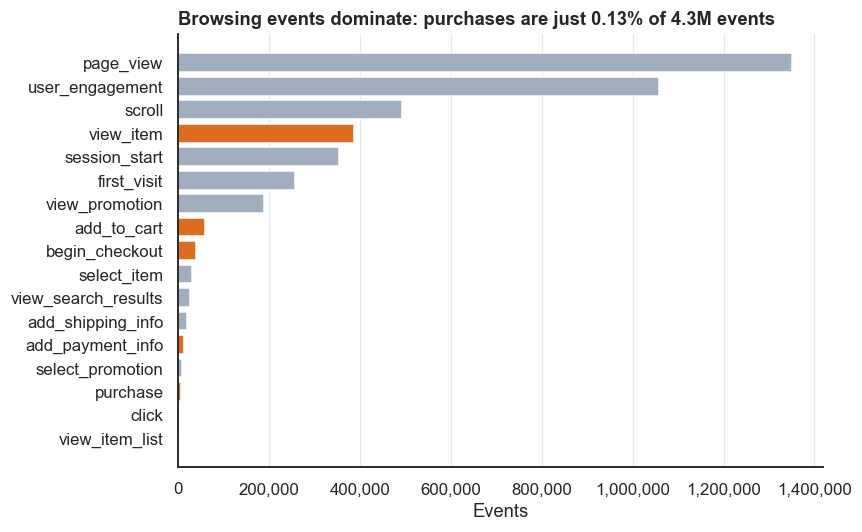

In [3]:
events = load("01_dq_events_by_name.csv")
fig, ax = plt.subplots(figsize=(8, 5))
colors = [ORANGE if e in {"view_item", "add_to_cart", "begin_checkout", "add_payment_info", "purchase"} else GREY for e in events.event_name]
ax.barh(events.event_name[::-1], events.events[::-1], color=colors[::-1])
thousands(ax)
light_grid(ax, "x")
ax.set_xlabel("Events")
ax.set_title("Browsing events dominate: purchases are just 0.13% of 4.3M events")
plt.tight_layout()
plt.show()

Page views, engagement and scroll events make up about two thirds of all traffic, while the funnel events (orange) are a small slice. Purchases are 5,692 raw events, which later shrinks after removing repeats and empty records.

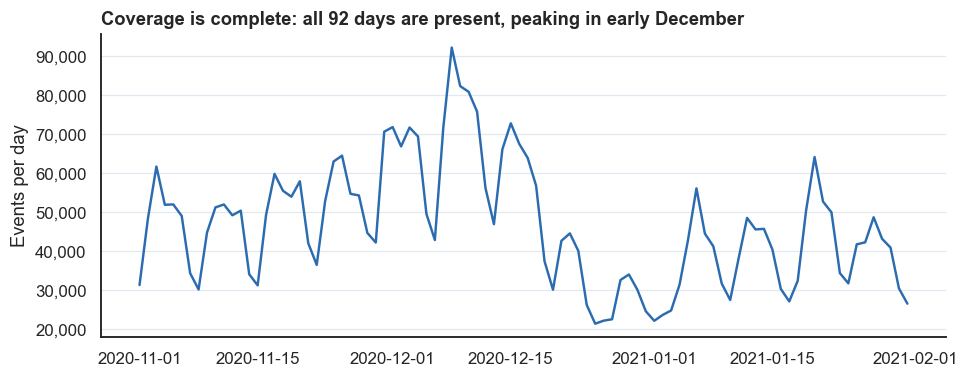

In [4]:
daily = load("01_dq_daily_events.csv")
daily["event_date"] = pd.to_datetime(daily["event_date"])
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(daily.event_date, daily.events, color=BLUE, lw=1.6)
thousands(ax, "y")
light_grid(ax, "y")
ax.set_ylabel("Events per day")
ax.set_title("Coverage is complete: all 92 days are present, peaking in early December")
plt.tight_layout()
plt.show()

There are no missing days. Traffic peaks in the first half of December and drops to its lowest points on 25 December and 1 January, so any holiday comparison has to be made against the early-November baseline and never year over year (there is no prior-year data).

## 3. Data quality

Google deliberately hides some values as `(data deleted)`, `<Other>` or nulls. They are reported here rather than silently dropped, and each analysis says how it handles them.

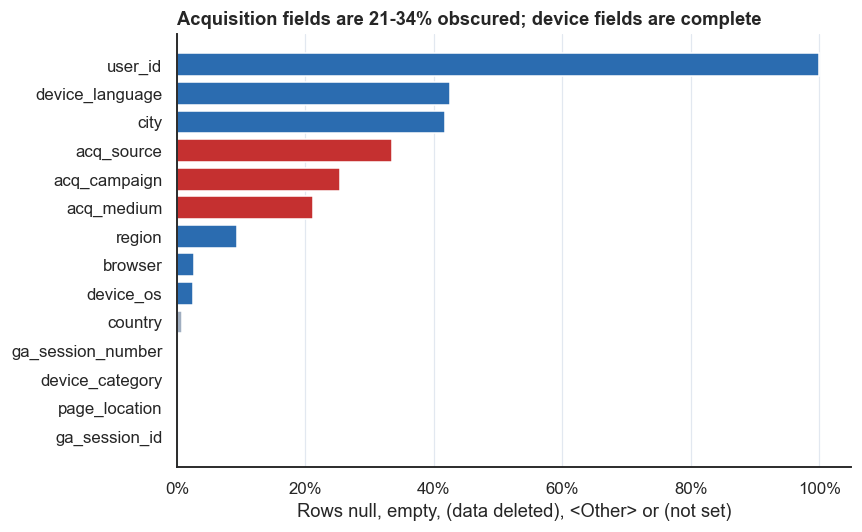

In [5]:
obs = load("01_dq_obscured_values.csv").sort_values("unusable_pct", ascending=True)
fig, ax = plt.subplots(figsize=(8, 5))
colors = [RED if c.startswith("acq_") else (GREY if p < 1 else BLUE) for c, p in zip(obs.column_name, obs.unusable_pct)]
ax.barh(obs.column_name, obs.unusable_pct, color=colors)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
light_grid(ax, "x")
ax.set_xlabel("Rows null, empty, (data deleted), <Other> or (not set)")
ax.set_title("Acquisition fields are 21-34% obscured; device fields are complete")
plt.tight_layout()
plt.show()

`user_id` is 100% null, so every user count uses `user_pseudo_id`. The acquisition fields (red) are the weak spot: 33.5% of events have an obscured source and 21.2% an obscured medium, so the channel analysis gets its own rows for obscured values. Country is only 0.75% `(not set)` but city is 41.8%, so city is not used. `device_category`, `ga_session_id` and `ga_session_number` are never missing, which makes the device and session logic reliable.

In [6]:
purchases = load("01_dq_purchases.csv").iloc[0]
sessions_checks = load("02_sessions_checks.csv").iloc[0]
clean = pd.DataFrame({
    "": ["Raw purchase events", "Clean orders"],
    "Count": [f"{purchases.purchase_events:,.0f}", f"{sessions_checks.orders:,.0f}"],
    "Revenue (USD)": [f"${purchases.total_revenue_usd:,.0f}", f"${sessions_checks.revenue_usd:,.0f}"],
})
clean

,,Count,Revenue (USD)
0,Raw purchase events,"5,692","$362,165"
1,Clean orders,"4,907","$339,457"


Raw purchase events overstate orders. Some transactions are logged more than once (326 transaction ids repeat, 335 extra events), and 883 purchase events have no usable transaction id, 450 of them with $0 revenue. An order is therefore one distinct real `transaction_id` (earliest event), plus id-less purchases that carry revenue. That gives **4,907 orders and $339,457**, about 6% less revenue than the raw events suggest.

In [7]:
start = load("01_dq_new_vs_returning_at_start.csv").iloc[0]
print(f"{start.returning_at_first_sight:,.0f} of {start.users:,.0f} users ({start.returning_at_first_sight_pct:.1f}%) already look 'returning' the first time they appear.")

9,006 of 270,154 users (3.3%) already look 'returning' the first time they appear.


Because the data starts on 1 Nov 2020, users who visited earlier look new. The session-number parameter fixes this: a user is **new** only if their lowest `ga_session_number` is 1 (261,148 users) and **returning** otherwise (9,006 users, 3.3%).

## 4. Funnel analysis

**Question:** which stage loses the largest share of potential customers?

The main funnel counts **users** and is **open**: a stage counts everyone who reached it, even if an earlier event was never recorded. A session-level version and a strict-sequence check are shown alongside. `add_shipping_info` is a diagnostic step, not one of the plan's seven stages.

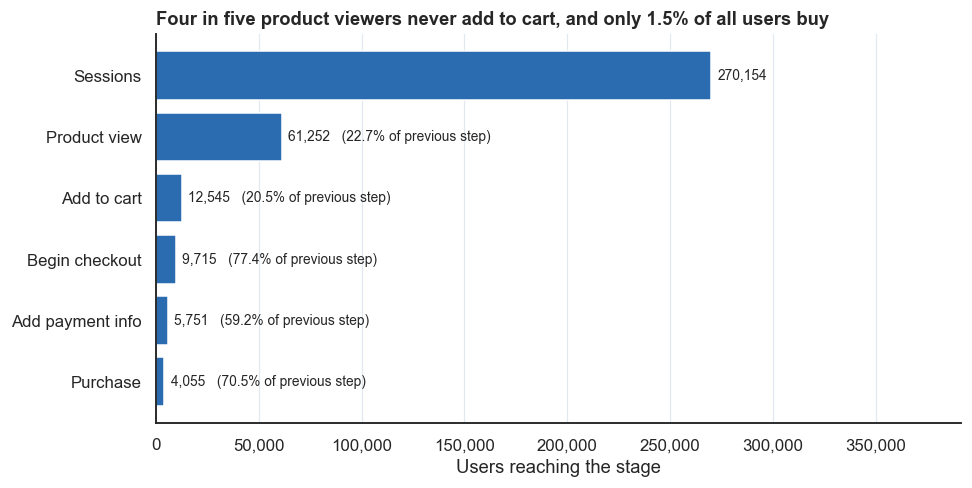

In [8]:
steps = load("04_funnel_steps.csv")
main = steps[~steps.is_diagnostic].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 4.6))
y = np.arange(len(main))[::-1]
ax.barh(y, main.users, color=BLUE)
for yi, row in zip(y, main.itertuples()):
    label = f"{row.users:,.0f}"
    if not np.isnan(row.users_step_conversion_pct) and row.stage_order > 1:
        label += f"   ({row.users_step_conversion_pct:.1f}% of previous step)"
    ax.text(row.users + 3000, yi, label, va="center", fontsize=9)
ax.set_yticks(y)
ax.set_yticklabels(main.stage)
thousands(ax)
light_grid(ax, "x")
ax.set_xlim(0, main.users.max() * 1.45)
ax.set_xlabel("Users reaching the stage")
ax.set_title("Four in five product viewers never add to cart, and only 1.5% of all users buy")
plt.tight_layout()
plt.show()

Of 270,154 users, 61,252 (22.7%) view a product, but only 20.5% of those add something to the cart. That step has the largest relative loss in the main funnel (79.5%), just ahead of the 77.3% who never view a product at all. Overall, 4,055 users buy: **1.50% of all users and 6.6% of product viewers**.

In [9]:
show = steps[["stage", "users", "users_step_conversion_pct", "users_overall_conversion_pct", "users_drop_off", "users_drop_off_pct", "sessions", "sessions_step_conversion_pct"]].copy()
show.columns = ["Stage", "Users", "Step conv. %", "Overall conv. %", "Users lost", "Relative drop-off %", "Sessions", "Sessions step conv. %"]
show.style.format({"Users": "{:,.0f}", "Sessions": "{:,.0f}", "Users lost": "{:,.0f}"}, na_rep="").hide(axis="index")

Stage,Users,Step conv. %,Overall conv. %,Users lost,Relative drop-off %,Sessions,Sessions step conv. %
Sessions,"270,154",,100.000000,,,"360,129",
Product view,"61,252",22.670000,22.670000,"208,902",77.330000,"77,020",21.390000
Add to cart,"12,545",20.480000,4.640000,"48,707",79.520000,"15,188",19.720000
Begin checkout,"9,715",77.440000,3.600000,"2,830",22.560000,"11,106",73.120000
Add shipping info (diagnostic),"9,714",99.990000,3.600000,1,0.010000,"11,105",99.990000
Add payment info,"5,751",59.200000,2.130000,"3,964",40.800000,"6,815",61.360000
Purchase,"4,055",70.510000,1.500000,"1,696",29.490000,"4,435",65.080000


The session-level funnel tells the same story with slightly lower conversion at every step (1.23% of sessions end in an order against 1.50% of users), because a user can browse in several sessions before buying. The diagnostic row shows that essentially everyone who begins checkout also adds shipping info (99.99%), so the two events fire together and the real loss happens right after, at the payment step.

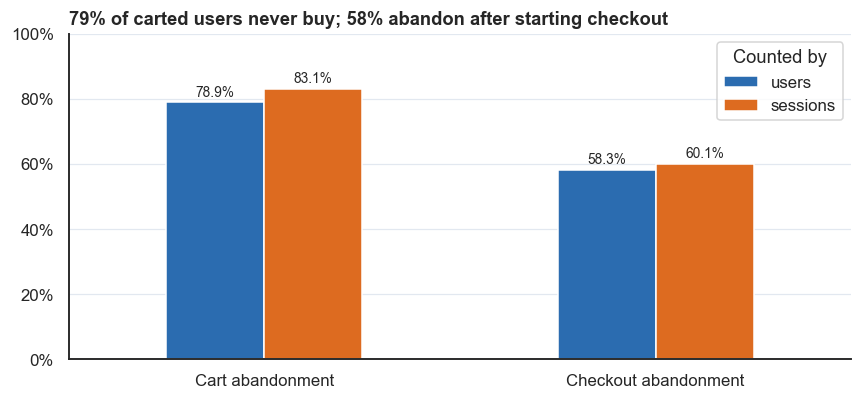

In [10]:
aband = load("04_funnel_abandonment.csv").set_index("level")
rates = pd.DataFrame({
    "Cart abandonment": aband.cart_abandonment_pct,
    "Checkout abandonment": aband.checkout_abandonment_pct,
}).loc[["users", "sessions"]]
ax = rates.T.plot.bar(figsize=(8, 3.8), color=[BLUE, ORANGE], rot=0)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
light_grid(ax, "y")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=2, fontsize=9)
ax.set_ylim(0, 100)
ax.legend(title="Counted by")
ax.set_title("79% of carted users never buy; 58% abandon after starting checkout")
plt.tight_layout()
plt.show()

Cart abandonment is the share of users who added to cart and did not buy (78.9% of users, 83.1% of sessions). Checkout abandonment is the share of users who began checkout and did not buy (58.3% of users, 60.1% of sessions). Inside checkout, 40.8% of users who begin never add payment info, which is the biggest drop between checkout and purchase.

### Is the open funnel hiding something?

An open funnel counts a stage even when an earlier event is missing. Here that matters, because many users reach checkout and even purchase without ever firing an `add_to_cart` event.

In [11]:
open_checks = load("04_funnel_open_checks.csv").iloc[0]
strict = load("04_funnel_strict_check.csv").iloc[0]

compare = pd.DataFrame({
    "Stage": ["Product view", "Add to cart", "Begin checkout", "Add payment info", "Purchase"],
    "Open funnel (users)": main.users.iloc[1:].astype(int).to_list(),
    "Strict sequence (users)": [strict.product_view, strict.add_to_cart, strict.begin_checkout, strict.add_payment_info, strict.purchase],
}).astype({"Strict sequence (users)": int})
compare["Step conv. open %"] = (compare["Open funnel (users)"] / compare["Open funnel (users)"].shift(1) * 100).round(1)
compare["Step conv. strict %"] = (compare["Strict sequence (users)"] / compare["Strict sequence (users)"].shift(1) * 100).round(1)
compare.style.format({"Open funnel (users)": "{:,.0f}", "Strict sequence (users)": "{:,.0f}"}, na_rep="").hide(axis="index")

Stage,Open funnel (users),Strict sequence (users),Step conv. open %,Step conv. strict %
Product view,"61,252","61,252",,
Add to cart,"12,545","12,539",20.500000,20.500000
Begin checkout,"9,715","5,656",77.400000,45.100000
Add payment info,"5,751","3,654",59.200000,64.600000
Purchase,"4,055","2,643",70.500000,72.300000


**Caveat on the cart-to-checkout step.** In the open funnel, 77.4% of users who add to cart go on to begin checkout. In a strict sequence it is only **45.1%**. The difference comes from users who never fired `add_to_cart`: 4,058 of the 9,715 users who began checkout (41.8%) and 1,412 of the 4,055 purchasers (34.8%). Possible reasons are items added to the cart before 1 Nov, a quick "buy now" path, or the event not firing on some pages. The sample cannot tell which. The safe reading is that **add to cart is not a reliable gate**, so the strongest and most robust findings are the 79% loss between product view and cart and the 41% who begin checkout but never add payment info, while the true cart-to-checkout loss lies somewhere between 23% and 55%.

## 5. Channel analysis

**Question:** which acquisition channels bring valuable customers, not just the most visitors?

This is **acquisition channel**: the earliest source and medium observed for each user that Google has not obscured. It is not the source of every visit, and about 10% of users show more than one real medium over the period. Values Google obscured get their own rows (`Other (obscured)` and `Data deleted`) instead of being dropped.

In [12]:
from scipy import stats


def wilson(successes, n, z=1.96):
    """95% Wilson score interval for a proportion."""
    p = successes / n
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return centre - half, centre + half


def two_prop_ztest(x1, n1, x2, n2):
    """Two-sided two-proportion z-test with a pooled standard error. Returns (diff, z, p)."""
    p1, p2 = x1 / n1, x2 / n2
    pooled = (x1 + x2) / (n1 + n2)
    se = np.sqrt(pooled * (1 - pooled) * (1 / n1 + 1 / n2))
    z = (p1 - p2) / se
    return p1 - p2, z, 2 * stats.norm.sf(abs(z))


perf = load("05_channel_performance.csv")
channels = perf[perf.acq_channel != "All users"].copy()
overall = perf[perf.acq_channel == "All users"].iloc[0]

table = channels[["acq_channel", "users", "pct_of_users", "purchasers", "conversion_rate_pct", "revenue_usd", "pct_of_revenue", "revenue_per_user", "aov"]].copy()
table.columns = ["Channel", "Users", "% of users", "Buyers", "Conversion %", "Revenue (USD)", "% of revenue", "Revenue / user", "AOV"]
table.style.format({"Users": "{:,.0f}", "Buyers": "{:,.0f}", "Revenue (USD)": "${:,.0f}", "Revenue / user": "${:.2f}", "AOV": "${:.2f}"}).hide(axis="index")

Channel,Users,% of users,Buyers,Conversion %,Revenue (USD),% of revenue,Revenue / user,AOV
Organic,"104,122",38.540000,"1,610",1.550000,"$131,260",38.670000,$1.26,$67.38
Direct,"66,233",24.520000,"1,068",1.610000,"$95,518",28.140000,$1.44,$72.25
Referral,"42,669",15.790000,889,2.080000,"$77,425",22.810000,$1.81,$71.29
Paid (cpc),"14,441",5.350000,209,1.450000,"$17,997",5.300000,$1.25,$74.68
Other (obscured),"40,863",15.130000,240,0.590000,"$15,058",4.440000,$0.37,$56.40
Data deleted,"1,826",0.680000,39,2.140000,"$2,199",0.650000,$1.20,$51.14


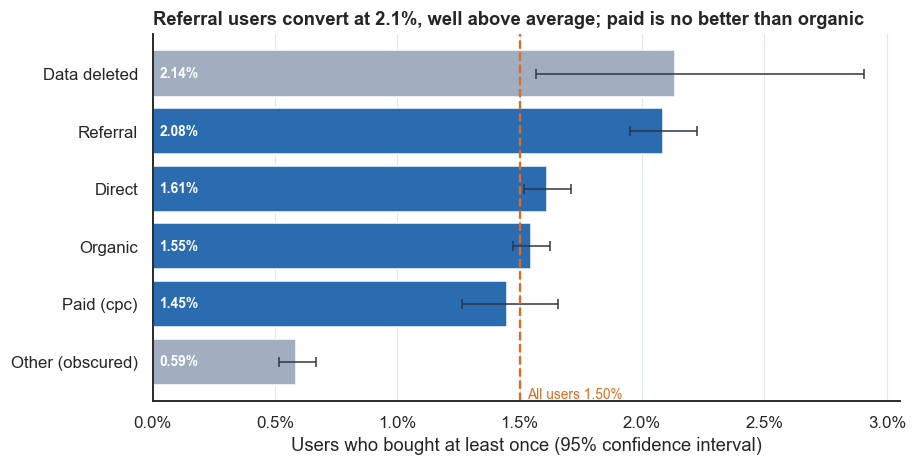

In [13]:
channels["lo"], channels["hi"] = zip(*[wilson(b, n) for b, n in zip(channels.purchasers, channels.users)])
plot = channels.copy()
plot["conv"] = plot.purchasers / plot.users * 100
plot["err_lo"] = plot.conv - plot.lo * 100
plot["err_hi"] = plot.hi * 100 - plot.conv
plot = plot.sort_values("conv")

fig, ax = plt.subplots(figsize=(8.5, 4.4))
colors = [GREY if o else BLUE for o in plot.is_obscured]
ax.barh(plot.acq_channel, plot.conv, xerr=[plot.err_lo, plot.err_hi], color=colors, error_kw={"ecolor": "#2d3748", "capsize": 3, "lw": 1})
ax.axvline(overall.conversion_rate_pct, color=ORANGE, ls="--", lw=1.5)
ax.text(overall.conversion_rate_pct + 0.03, -0.45, f"All users {overall.conversion_rate_pct:.2f}%", color=ORANGE, fontsize=9, va="top")
for yi, c in enumerate(plot.conv):
    ax.text(0.03, yi, f"{c:.2f}%", va="center", color="white", fontsize=9, fontweight="bold")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
light_grid(ax, "x")
ax.set_xlabel("Users who bought at least once (95% confidence interval)")
ax.set_title("Referral users convert at 2.1%, well above average; paid is no better than organic")
plt.tight_layout()
plt.show()

In [14]:
organic = channels[channels.acq_channel == "Organic"].iloc[0]
referral = channels[channels.acq_channel == "Referral"].iloc[0]
paid = channels[channels.acq_channel == "Paid (cpc)"].iloc[0]
direct = channels[channels.acq_channel == "Direct"].iloc[0]

tests = []
for name, other in [("Referral vs Organic", referral), ("Paid (cpc) vs Organic", paid), ("Direct vs Organic", direct)]:
    diff, z, p = two_prop_ztest(other.purchasers, other.users, organic.purchasers, organic.users)
    tests.append({"Comparison": name, "Difference (pp)": diff * 100, "z": z, "p-value": p, "Significant (p < 0.05)": "yes" if p < 0.05 else "no"})
pd.DataFrame(tests).style.format({"Difference (pp)": "{:+.2f}", "z": "{:.2f}", "p-value": "{:.2g}"}).hide(axis="index")

Comparison,Difference (pp),z,p-value,Significant (p < 0.05)
Referral vs Organic,+0.54,7.22,5e-13,yes
Paid (cpc) vs Organic,-0.10,-0.91,0.36,no
Direct vs Organic,+0.07,1.07,0.28,no


**Referral is the standout.** Referral users are 15.8% of the audience but buy at **2.08% against 1.55% for organic** (a gap of 0.54 percentage points, z = 7.2, p < 0.001), and each referral user is worth $1.82 in revenue against a $1.26 average. **Paid (cpc) gives no premium**: 1.45% against 1.55% for organic is not a significant difference (p = 0.36), and revenue per user ($1.25) matches organic ($1.26). Paid does have the highest average order value ($74.68), but the sample has no ad-spend data, so this says nothing about return on spend. Direct (1.61%) is also above organic, but that gap is not statistically significant. The grey `Data deleted` bar (2.14%) is the highest on the chart, but it covers only 1,826 users, so its interval is very wide and it is not evidence of a strong channel.

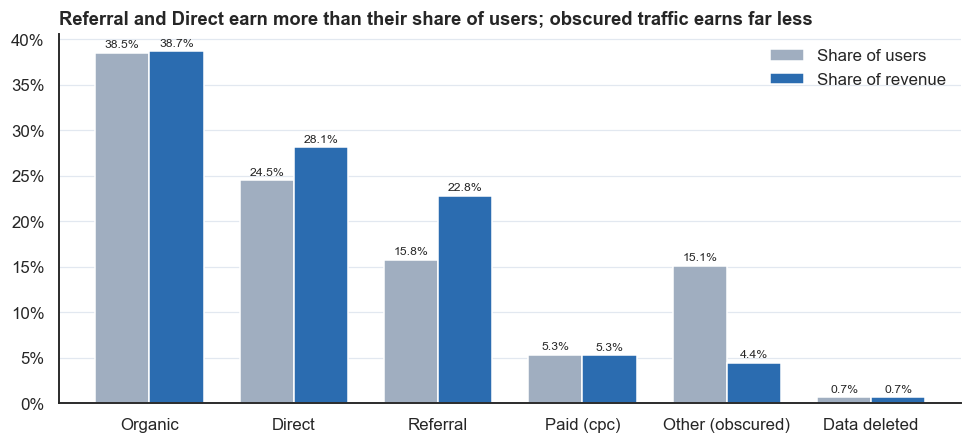

In [15]:
share = channels.set_index("acq_channel")[["pct_of_users", "pct_of_revenue"]].loc[["Organic", "Direct", "Referral", "Paid (cpc)", "Other (obscured)", "Data deleted"]]
ax = share.plot.bar(figsize=(9, 4.2), color=[GREY, BLUE], rot=0, width=0.75)
light_grid(ax, "y")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=2, fontsize=8)
ax.legend(["Share of users", "Share of revenue"], frameon=False)
ax.set_xlabel("")
ax.set_title("Referral and Direct earn more than their share of users; obscured traffic earns far less")
plt.tight_layout()
plt.show()

Organic earns almost exactly its share (38.5% of users, 38.7% of revenue). Referral punches above its weight (15.8% of users, 22.8% of revenue) and so does Direct (24.5% and 28.1%). The `Other (obscured)` group is the opposite: **15.1% of users but only 4.4% of revenue** ($0.37 per user, 0.59% conversion). Those users also rarely come back (1.04 sessions per user against 1.33 overall) and stall in checkout, as the next chart shows.

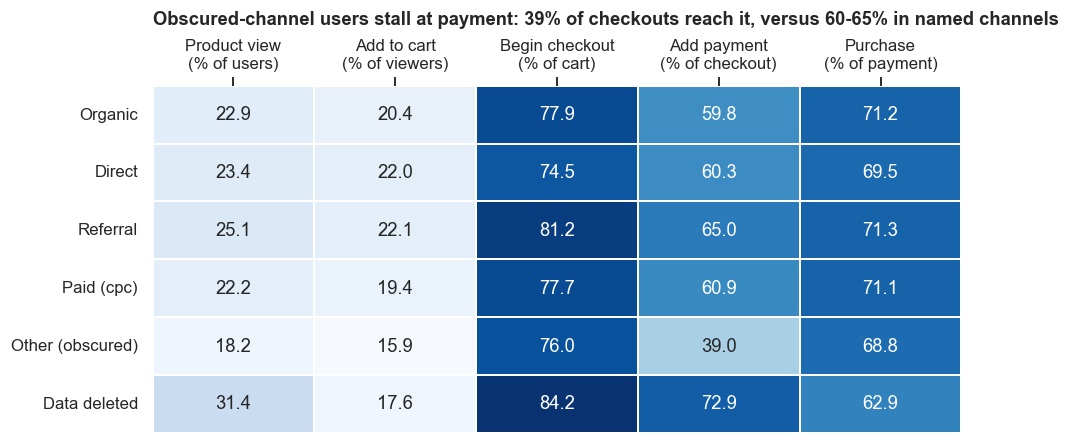

In [16]:
funnel = load("05_channel_funnel.csv").set_index("acq_channel").loc[["Organic", "Direct", "Referral", "Paid (cpc)", "Other (obscured)", "Data deleted"]]
heat = funnel[["view_pct_of_users", "cart_pct_of_view", "checkout_pct_of_cart", "payment_pct_of_checkout", "purchase_pct_of_payment"]]
heat.columns = ["Product view\n(% of users)", "Add to cart\n(% of viewers)", "Begin checkout\n(% of cart)", "Add payment\n(% of checkout)", "Purchase\n(% of payment)"]
fig, ax = plt.subplots(figsize=(9, 4.2))
sns.heatmap(heat, annot=True, fmt=".1f", cmap="Blues", cbar=False, linewidths=1, linecolor="white", ax=ax, vmin=15, vmax=85)
ax.set_ylabel("")
ax.xaxis.tick_top()
ax.set_title("Obscured-channel users stall at payment: 39% of checkouts reach it, versus 60-65% in named channels", pad=40)
plt.tight_layout()
plt.show()

Across the four named channels the funnel looks alike: roughly a fifth of product viewers add to cart and about 70% of payments complete. The main differences are that referral users are more likely to view a product (25.1% against 22.9% for organic) and to continue through checkout (65.0% reach payment against 59.8%), and that the obscured group loses most people between starting checkout and adding payment details (39.0%). Because Google hides what these users actually are, this could be low-quality traffic, bots, or a tracking artefact; the sample cannot say which.

In [17]:
sources = load("05_channel_sources.csv")
src = sources[["acq_channel", "acq_medium", "acq_source", "users", "conversion_rate_pct", "revenue_usd", "revenue_per_user"]].copy()
src.columns = ["Channel", "Medium", "Source", "Users", "Conversion %", "Revenue (USD)", "Revenue / user"]
src.style.format({"Users": "{:,.0f}", "Revenue (USD)": "${:,.0f}", "Revenue / user": "${:.2f}"}).hide(axis="index")

Channel,Medium,Source,Users,Conversion %,Revenue (USD),Revenue / user
Organic,organic,google,"95,255",1.550000,"$120,324",$1.26
Direct,(none),(direct),"66,233",1.610000,"$95,518",$1.44
Other (obscured),,,"40,862",0.590000,"$15,058",$0.37
Referral,referral,,"26,306",1.780000,"$39,363",$1.50
Referral,referral,shop.googlemerchandisestore.com,"16,362",2.580000,"$38,062",$2.33
Paid (cpc),cpc,google,"14,441",1.450000,"$17,997",$1.25
Organic,organic,,"8,867",1.470000,"$10,936",$1.23
Data deleted,(data deleted),(data deleted),"1,785",2.130000,"$2,167",$1.21


**Caveats for the channel analysis.** The best-performing referral source is `shop.googlemerchandisestore.com` (2.58% conversion, $2.33 per user, 16,362 users), which looks like the store's own domain rather than an outside partner; if so, it is a cross-domain or self-referral effect and should not be read as a marketing channel. The other referral users, whose source Google obscured, still convert at 1.78%, above organic. Everything here is observational: the channels differ in audience as well as in quality, so these results show where value comes from, not what would happen if spend moved.

## 6. Device and country analysis

**Question:** where does the funnel diverge by device, and which markets deserve focus?

A device belongs to a *session* (one person can use a phone and a laptop), so the device comparison counts **sessions**. A user-level version, using each user's first device, is used as a robustness check. Funnel stages are open, as before.

In [18]:
dev = load("06_device_funnel_sessions.csv").set_index("device_category").loc[["desktop", "mobile", "tablet"]]

summary = dev[["sessions", "pct_of_sessions", "orders", "revenue_usd", "pct_of_revenue", "conversion_rate_pct", "revenue_per_session", "aov"]].reset_index()
summary.columns = ["Device", "Sessions", "% of sessions", "Orders", "Revenue (USD)", "% of revenue", "Conversion % (sessions)", "Revenue / session", "AOV"]
summary.style.format({"Sessions": "{:,.0f}", "Orders": "{:,.0f}", "Revenue (USD)": "${:,.0f}", "Revenue / session": "${:.2f}", "AOV": "${:.2f}"}).hide(axis="index")

Device,Sessions,% of sessions,Orders,Revenue (USD),% of revenue,Conversion % (sessions),Revenue / session,AOV
desktop,"208,942",58.020000,"2,818","$196,583",57.910000,1.210000,$0.94,$69.76
mobile,"143,185",39.760000,"1,997","$136,921",40.340000,1.270000,$0.96,$68.56
tablet,"8,002",2.220000,92,"$5,953",1.750000,1.140000,$0.74,$64.71


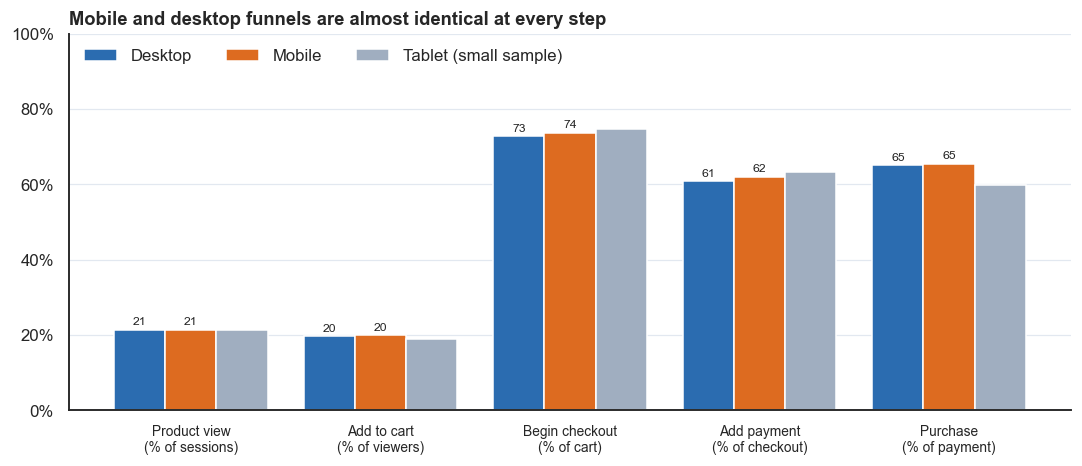

In [19]:
steps = [
    ("Product view\n(% of sessions)", "view_pct_of_sessions"),
    ("Add to cart\n(% of viewers)", "cart_pct_of_view"),
    ("Begin checkout\n(% of cart)", "checkout_pct_of_cart"),
    ("Add payment\n(% of checkout)", "payment_pct_of_checkout"),
    ("Purchase\n(% of payment)", "purchase_pct_of_payment"),
]
x = np.arange(len(steps))
width = 0.27
fig, ax = plt.subplots(figsize=(10, 4.4))
palette = {"desktop": BLUE, "mobile": ORANGE, "tablet": GREY}
for i, device in enumerate(["desktop", "mobile", "tablet"]):
    vals = [dev.loc[device, col] for _, col in steps]
    bars = ax.bar(x + (i - 1) * width, vals, width, label=device.capitalize() + (" (small sample)" if device == "tablet" else ""), color=palette[device])
    if device != "tablet":
        ax.bar_label(bars, fmt="%.0f", padding=2, fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels([s for s, _ in steps], fontsize=9)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
light_grid(ax, "y")
ax.set_ylim(0, 100)
ax.legend(frameon=False, ncol=3, loc="upper left")
ax.set_title("Mobile and desktop funnels are almost identical at every step")
plt.tight_layout()
plt.show()

In [20]:
stages = [
    ("Product view (of sessions)", "product_view", "sessions"),
    ("Add to cart (of viewers)", "add_to_cart", "product_view"),
    ("Begin checkout (of cart)", "begin_checkout", "add_to_cart"),
    ("Add payment (of checkout)", "add_payment_info", "begin_checkout"),
    ("Purchase (of payment)", "purchase", "add_payment_info"),
    ("Overall conversion (of sessions)", "purchase", "sessions"),
]
rows = []
for label, num, den in stages:
    diff, z, p = two_prop_ztest(dev.loc["mobile", num], dev.loc["mobile", den], dev.loc["desktop", num], dev.loc["desktop", den])
    rows.append({
        "Step": label,
        "Mobile %": dev.loc["mobile", num] / dev.loc["mobile", den] * 100,
        "Desktop %": dev.loc["desktop", num] / dev.loc["desktop", den] * 100,
        "Gap (pp)": diff * 100,
        "z": z,
        "p-value": p,
        "Significant (p < 0.05)": "yes" if p < 0.05 else "no",
    })
device_tests = pd.DataFrame(rows)
biggest = device_tests.loc[device_tests["Gap (pp)"].abs().idxmax(), "Step"]
print(f"Biggest mobile-vs-desktop gap by size: {biggest}")
device_tests.style.format({"Mobile %": "{:.2f}", "Desktop %": "{:.2f}", "Gap (pp)": "{:+.2f}", "z": "{:+.2f}", "p-value": "{:.3f}"}).hide(axis="index")

Biggest mobile-vs-desktop gap by size: Add payment (of checkout)


Step,Mobile %,Desktop %,Gap (pp),z,p-value,Significant (p < 0.05)
Product view (of sessions),21.30,21.45,-0.15,-1.06,0.291,no
Add to cart (of viewers),19.92,19.61,+0.31,+1.06,0.291,no
Begin checkout (of cart),73.62,72.72,+0.90,+1.22,0.222,no
Add payment (of checkout),62.09,60.78,+1.31,+1.38,0.167,no
Purchase (of payment),65.44,65.02,+0.42,+0.36,0.721,no
Overall conversion (of sessions),1.27,1.21,+0.06,+1.60,0.109,no


In [21]:
tablet_diff, tablet_z, tablet_p = two_prop_ztest(dev.loc["tablet", "purchase"], dev.loc["tablet", "add_payment_info"], dev.loc["desktop", "purchase"], dev.loc["desktop", "add_payment_info"])
users_dev = load("06_device_funnel_users.csv").set_index("device_category")
u_diff, u_z, u_p = two_prop_ztest(users_dev.loc["mobile", "purchase"], users_dev.loc["mobile", "users"], users_dev.loc["desktop", "purchase"], users_dev.loc["desktop", "users"])
print(f"Tablet vs desktop, purchase step ({int(dev.loc['tablet', 'add_payment_info'])} tablet payment sessions): gap {tablet_diff * 100:+.2f} pp, p = {tablet_p:.3f}")
print(f"Robustness, user level (first device): mobile {users_dev.loc['mobile', 'conversion_rate_pct']:.2f}% vs desktop {users_dev.loc['desktop', 'conversion_rate_pct']:.2f}%, gap {u_diff * 100:+.2f} pp, p = {u_p:.3f}")

Tablet vs desktop, purchase step (152 tablet payment sessions): gap -5.15 pp, p = 0.192
Robustness, user level (first device): mobile 1.54% vs desktop 1.48%, gap +0.06 pp, p = 0.204


**The device is not where the funnel breaks.** Desktop and mobile follow the same path: about 21% of sessions view a product, 20% of viewers add to cart, 73% continue to checkout, 61-62% add payment and 65% complete. No step differs significantly (every p-value is above 0.16). The largest gap in size is at the payment step, and it favours mobile (62.1% against 60.8%, p = 0.17). Overall, mobile sessions convert at 1.27% against 1.21% on desktop (p = 0.11, not significant). The user-level check agrees (1.54% against 1.48%, p = 0.20). Mobile is 40% of sessions and 40% of revenue, in line with its traffic.

**Tablet** is only 2.2% of sessions and its biggest gap (5.2 points lower at the purchase step) rests on 152 payment sessions, so it is too small to be a finding (p = 0.19). Average order value is similar across devices ($64.71 to $69.76).

So this analysis does **not** support the idea that mobile checkout is the problem. A mobile checkout redesign would not be justified by this data; the loss points identified in the funnel affect all devices alike.

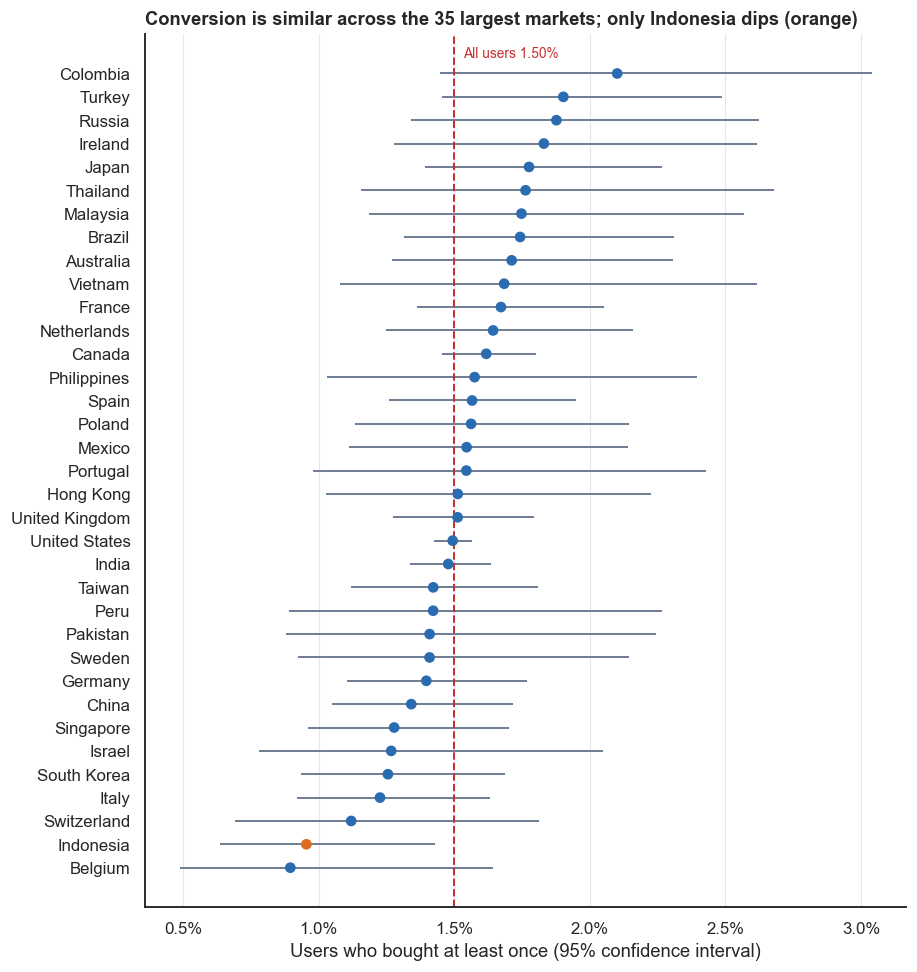

35 countries have at least 1,000 users and hold 92.4% of all users.
Nominally significant vs the rest (p < 0.05, uncorrected): 1. After Bonferroni correction (p < 0.0014): 0.


In [22]:
c = load("06_country_performance.csv")
total_users, total_buyers = c.users.sum(), c.purchasers.sum()
MIN_USERS = 1000
big = c[(c.users >= MIN_USERS) & (c.country != "(not set)")].copy()

res = []
for r in big.itertuples():
    diff, z, p = two_prop_ztest(r.purchasers, r.users, total_buyers - r.purchasers, total_users - r.users)
    lo, hi = wilson(r.purchasers, r.users)
    res.append({"country": r.country, "users": r.users, "buyers": r.purchasers, "conv": r.purchasers / r.users * 100, "lo": lo * 100, "hi": hi * 100,
                "diff_vs_rest": diff * 100, "p": p, "revenue": r.revenue_usd, "pct_users": r.pct_of_users, "pct_revenue": r.pct_of_revenue})
res = pd.DataFrame(res).sort_values("conv")
overall_conv = total_buyers / total_users * 100

fig, ax = plt.subplots(figsize=(8.5, 9))
colors = [ORANGE if p < 0.05 else BLUE for p in res.p]
ax.hlines(res.country, res.lo, res.hi, color="#718096", lw=1.3)
ax.scatter(res.conv, res.country, color=colors, zorder=3, s=36)
ax.axvline(overall_conv, color=RED, ls="--", lw=1.3)
ax.text(overall_conv + 0.03, len(res) - 0.3, f"All users {overall_conv:.2f}%", color=RED, fontsize=9)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
light_grid(ax, "x")
ax.set_xlabel("Users who bought at least once (95% confidence interval)")
ax.set_title("Conversion is similar across the 35 largest markets; only Indonesia dips (orange)")
plt.tight_layout()
plt.show()
print(f"{len(res)} countries have at least {MIN_USERS:,} users and hold {res.users.sum() / total_users * 100:.1f}% of all users.")
print(f"Nominally significant vs the rest (p < 0.05, uncorrected): {(res.p < 0.05).sum()}. After Bonferroni correction (p < {0.05 / len(res):.4f}): {(res.p < 0.05 / len(res)).sum()}.")

In [23]:
watch = res.sort_values("conv").head(5)[["country", "users", "buyers", "conv", "diff_vs_rest", "p"]].copy()
watch.columns = ["Country", "Users", "Buyers", "Conversion %", "Gap vs rest (pp)", "p-value"]
print("Lowest conversion among markets with 1,000+ users:")
display(watch.style.format({"Users": "{:,.0f}", "Conversion %": "{:.2f}", "Gap vs rest (pp)": "{:+.2f}", "p-value": "{:.3f}"}).hide(axis="index"))

small = c[c.users < MIN_USERS].sort_values("conversion_rate_pct", ascending=False).head(5)[["country", "users", "purchasers", "conversion_rate_pct"]].copy()
small.columns = ["Country", "Users", "Buyers", "Conversion %"]
print("Why a minimum user count matters: the top 'conversion' scores among tiny markets")
display(small.style.format({"Users": "{:,.0f}", "Conversion %": "{:.2f}"}).hide(axis="index"))

Lowest conversion among markets with 1,000+ users:


Country,Users,Buyers,Conversion %,Gap vs rest (pp),p-value
Belgium,"1,116",10,0.90,-0.61,0.096
Indonesia,"2,408",23,0.96,-0.55,0.027
Switzerland,"1,428",16,1.12,-0.38,0.236
Italy,"3,750",46,1.23,-0.28,0.164
South Korea,"3,424",43,1.26,-0.25,0.235


Why a minimum user count matters: the top 'conversion' scores among tiny markets


Country,Users,Buyers,Conversion %
Uruguay,104,6,5.77
Macao,55,2,3.64
Malta,57,2,3.51
Dominican Republic,154,5,3.25
Guatemala,93,3,3.23


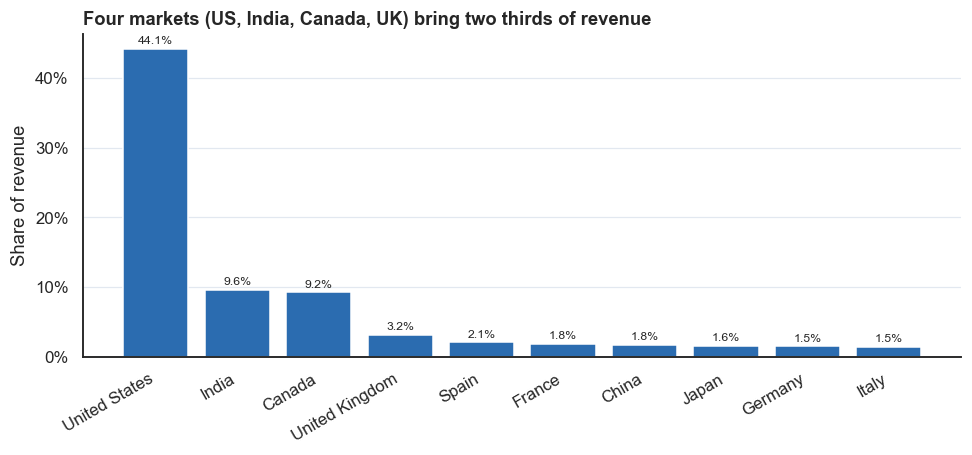

In [24]:
top = c.sort_values("revenue_usd", ascending=False).head(10).copy()
top["cum_pct"] = top.pct_of_revenue.cumsum()
fig, ax = plt.subplots(figsize=(9, 4.3))
ax.bar(top.country, top.pct_of_revenue, color=BLUE)
ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=2, fontsize=8)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
light_grid(ax, "y")
ax.set_ylabel("Share of revenue")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
ax.set_title("Four markets (US, India, Canada, UK) bring two thirds of revenue")
plt.tight_layout()
plt.show()

**Country conversion does not separate the markets.** Of 109 countries, 35 have at least 1,000 users and together hold 92.4% of all users. Their conversion rates range from about 1% to 2.1% around the 1.50% average, but with this few buyers per country almost none of that is distinguishable from chance. Only Indonesia stands out (0.96% on 2,408 users, 23 buyers, p = 0.027), and that does not survive a correction for running 35 comparisons. Among markets with 3,000 or more users, Italy (1.23%), South Korea (1.26%) and Singapore (1.28%) have the lowest rates, and they are a watch list rather than a conclusion. Without a minimum user count the ranking would be dominated by tiny markets such as Uruguay (5.8% from 6 buyers).

**Revenue is concentrated, so focus follows size.** The United States (44.1% of revenue), India (9.6%), Canada (9.2%) and the United Kingdom (3.2%) bring 66% of revenue. Canada earns more than its 7.5% share of users (9.2% of revenue, $1.55 per user against $1.26 overall), mostly through a higher average order value ($76.88 against $69.18) and slightly higher conversion (1.62%, a gap that is not statistically significant). Country is a useful way to size the opportunity, but this sample does not show a market with a clearly broken funnel.